In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load dataset
df = pd.read_csv('DATA AI - Cut.csv')

# 2. Encode pollution levels
df['Polusi_Angka'] = df['Kategori Paparan Polusi'].map({'Rendah': 0, 'Sedang': 1, 'Tinggi': 2})

# 3. Define Features (X) and Target (Y)
X = df[['Asam Askorbat (mg/g)', 'Total Klorofil', 'Kadar Ph', 'Kadar Air', 'Polusi_Angka']]
Y = df['Label Toleransi']

plant_names = df['Nama Latin']

# 4. Split data
X_train, X_test, Y_train, Y_test, names_train, names_test = train_test_split(
    X, Y, plant_names, test_size=0.2, random_state=42
)

# 5. Build Random Forest
# n_estimators=100 -> planting 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the forest
rf_model.fit(X_train, Y_train)

# 6. Test AI predictions on unseen data
rf_predictions = rf_model.predict(X_test)

# 7. Check Accuracy
rf_score = accuracy_score(Y_test, rf_predictions)
print(f"Random Forest Accuracy Score: {rf_score * 100:.2f}%\n")

# 8. Show results
results_df = pd.DataFrame({
    'Nama Latin': names_test,
    'Real Label': Y_test,
    'RF Predicted Label': rf_predictions
})

print("Sample of Random Forest Predictions:")
print(results_df.head(20))

Random Forest Accuracy Score: 75.93%

Sample of Random Forest Predictions:
                           Nama Latin   Real Label RF Predicted Label
181                   Albizia lebbeck     Sensitif           Sensitif
119                     Plumeria alba      Moderat            Moderat
139                     Bixa orellana  Intermediet        Intermediet
216                   Ficus benjamina     Sensitif           Sensitif
45                    Murraya exotica      Toleran            Toleran
256            Schefflera grandiflora     Sensitif           Sensitif
146                 Cosmos Sulphureus  Intermediet           Sensitif
115               Nephelium lappaceum      Moderat            Moderat
97                        Ficus panda      Moderat            Moderat
86                Cynometra ramiflora      Moderat            Moderat
82                       Citrus limon      Moderat            Moderat
73               Bougainvillea glabra      Moderat            Toleran
237            

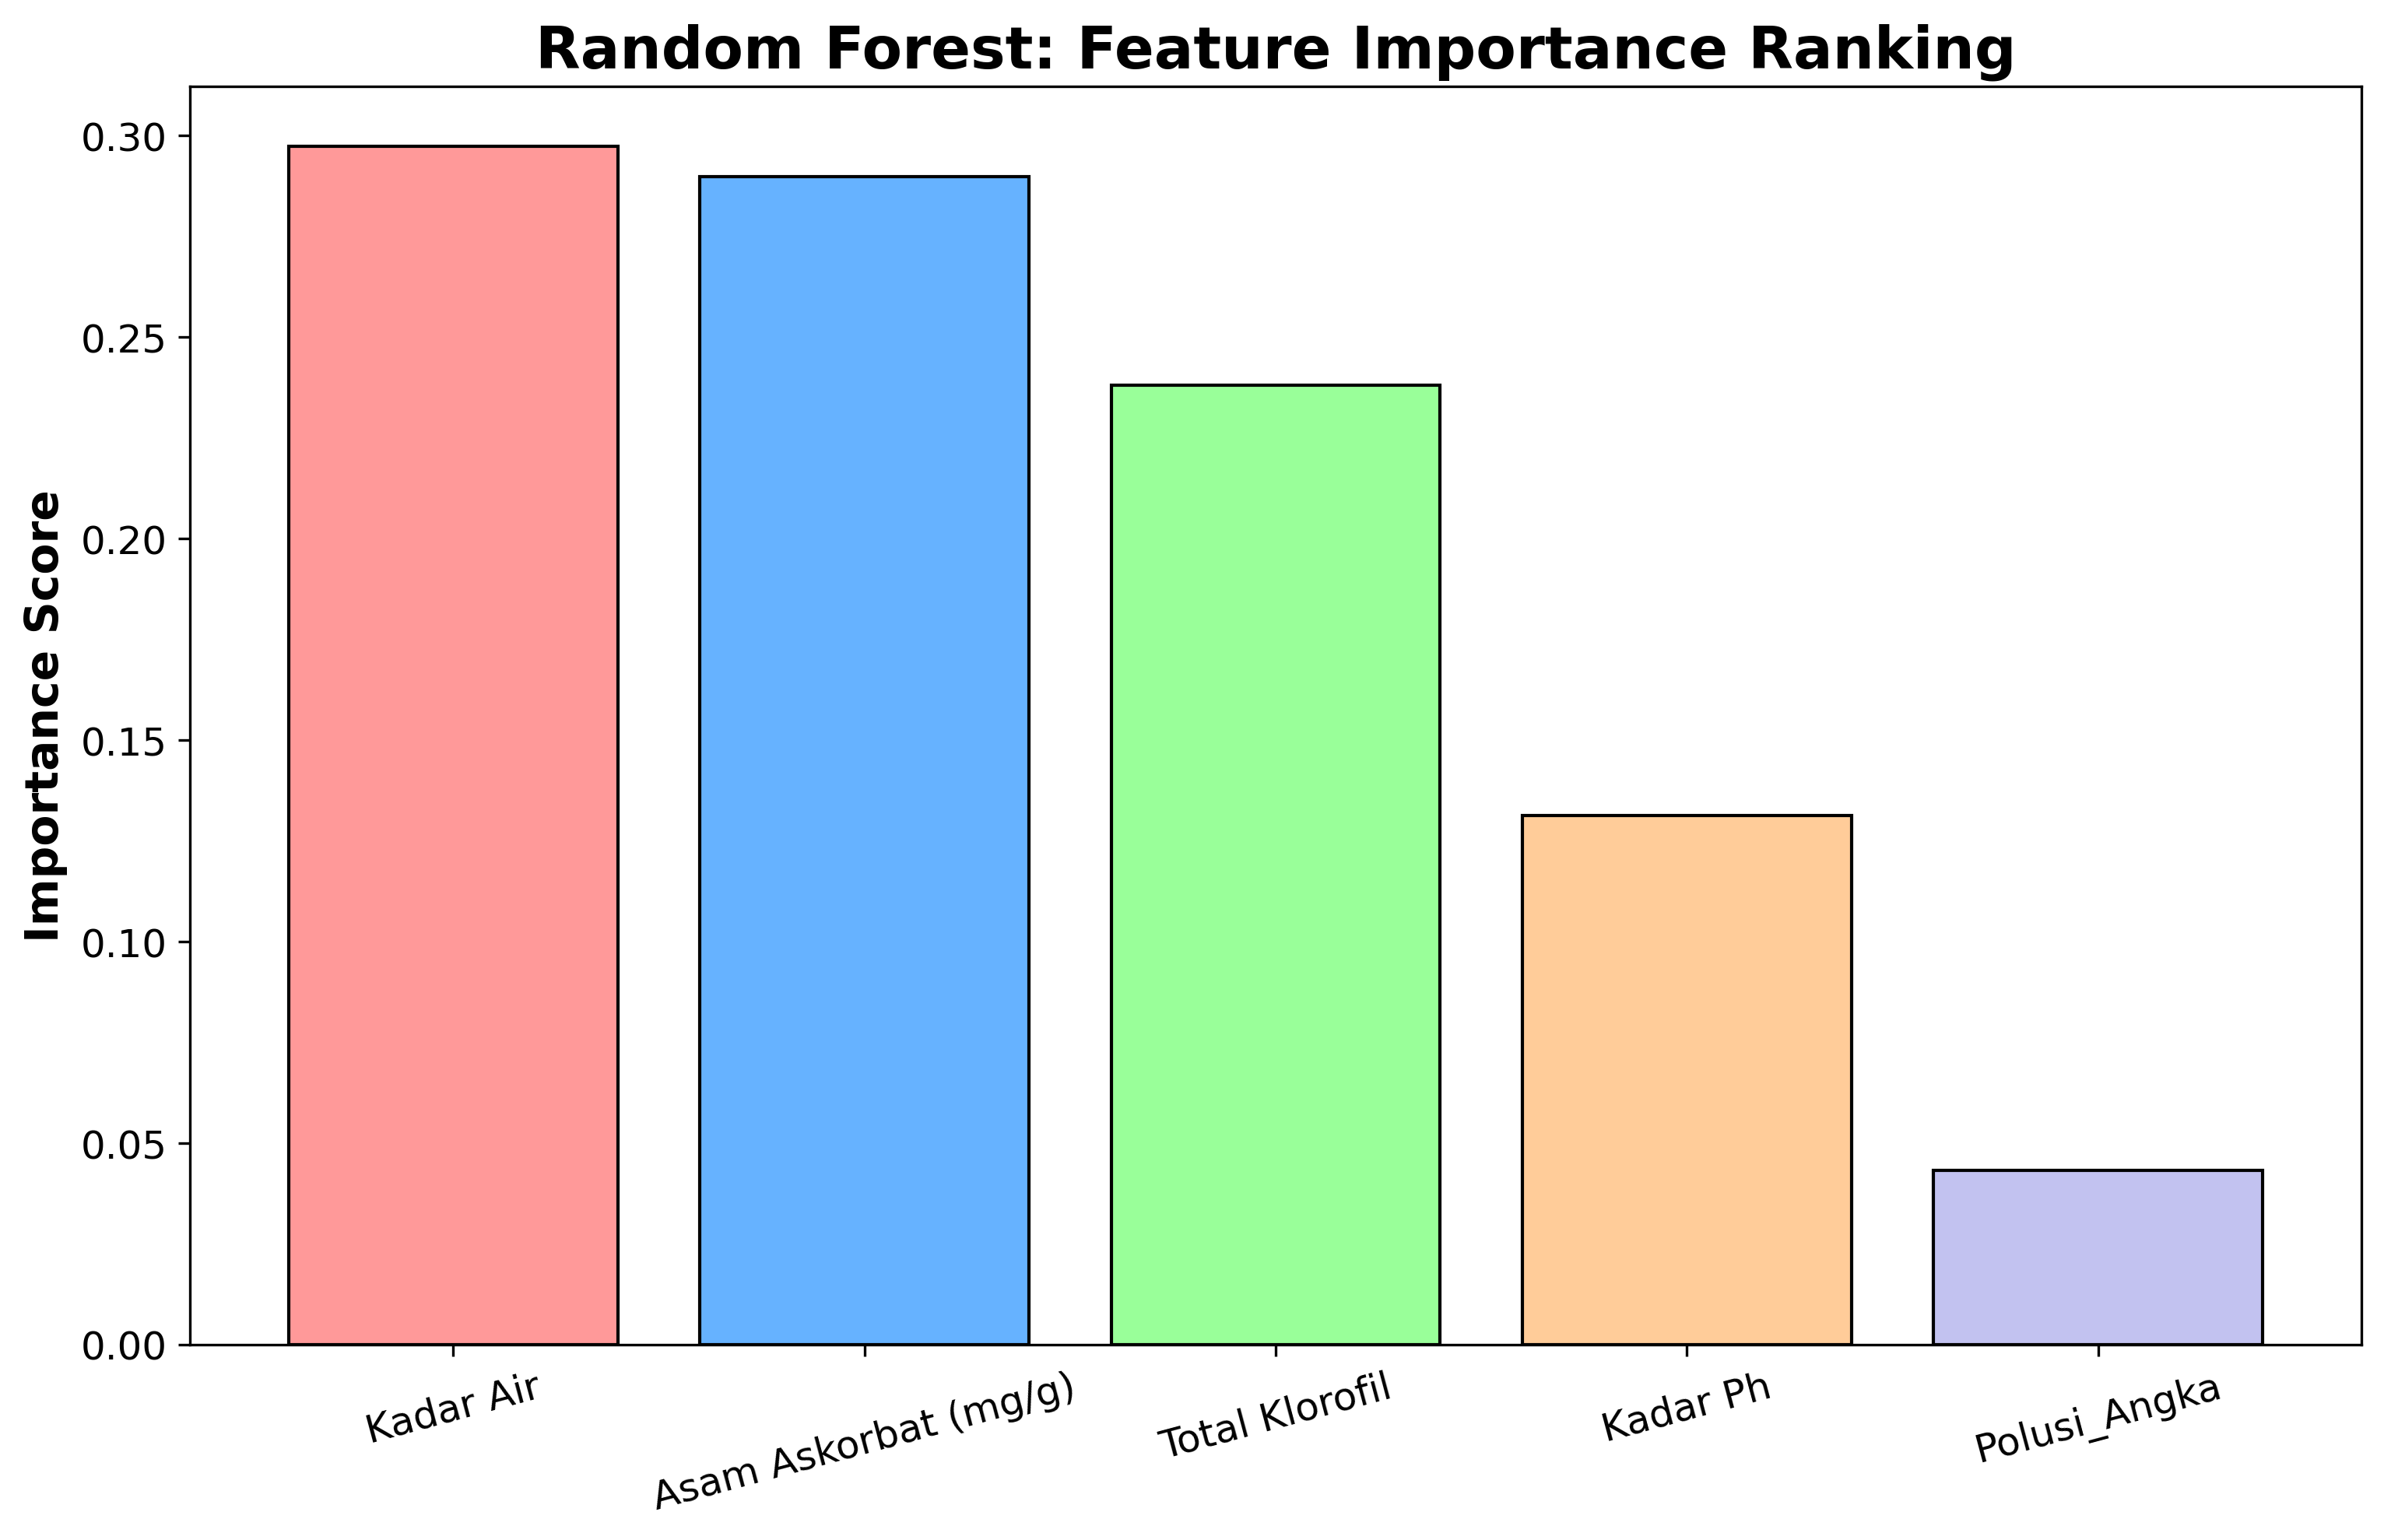

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the importance scores from trained Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Sort from highest to lowest
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# 3. Draw Bar Chart
plt.figure(figsize=(12, 7), dpi=300)

colors = ['#ff9999', '#66b2ff', '#99ff99', '#ffcc99', '#c2c2f0']
plt.bar(range(len(importances)), sorted_importances, color=colors, edgecolor='black')

plt.xticks(range(len(importances)), sorted_features, rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Importance Score', fontsize=14, fontweight='bold')
plt.title('Random Forest: Feature Importance Ranking', fontsize=18, fontweight='bold')

plt.savefig('Feature_Importance_Chart.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv_model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf_cv_model, X, Y, cv=5)

print(f"Accuracy for each of the 5 rounds: {scores}")
print(f"K-Fold Average Accuracy: {scores.mean() * 100:.2f}%")

Accuracy for each of the 5 rounds: [0.7962963  0.75471698 0.75471698 0.71698113 0.71698113]
K-Fold Average Accuracy: 74.79%
